In [219]:
# Main environment setup
# Comment: install only what you need in your environment.
# The original notebook used CLIP-specific installs; this notebook switches to LLaVA/TRL/PEFT.

#!pip install -U datasets huggingface_hub torch torchvision Pillow numpy pandas scipy scikit-image tqdm matplotlib
#!pip install -U transformers accelerate trl peft bitsandbytes tensorboard sentencepiece
# Optional:
#!pip install -U hf_xet

import os
import io
import re
import ast
import json
import math
import time
import copy
import random
import pathlib
import functools
from dataclasses import dataclass
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import io
import base64

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset, DatasetDict, load_dataset
from scipy.spatial import KDTree
from skimage.draw import line_aa
from skimage.draw import line as sk_line

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    LlavaNextProcessor,
    LlavaNextForConditionalGeneration
)
from peft import (
    LoraConfig,
    IA3Config,
    get_peft_model,
    prepare_model_for_kbit_training,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print(f"torch        : {torch.__version__}")
print(f"device       : {DEVICE}")
print(f"bf16 support : {torch.cuda.is_available() and torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False}")


torch        : 2.8.0+cu128
device       : cuda
bf16 support : True


In [ ]:
# Global configuration

CFG = {
    # Data / task settings
    "embodiment": "Legged Robot",
    "val_split": 0.20,
    "seed": 42,

    # Quick experiment testing:
    "max_train_samples": None,      
    "max_val_samples": None,
    "max_test_samples": None,

    # Model settings:
    "model_id": "llava-hf/llava-v1.6-mistral-7b-hf",
    "image_max_side": 672,           
    "max_new_tokens": 800,
    "generation_num_beams": 1,

    # Training settings
    "num_train_epochs": 100,
    "learning_rate": 2e-5,
    "weight_decay": 1e-4,
    "warmup_ratio": 0.03,
    "patience": 10, # Stopping criteria if val loss does not improve after n epochs
    "per_device_train_batch_size": 1,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": 8,
    "logging_steps": 10,
    "save_strategy": "epoch",
    "eval_strategy": "epoch",
    "save_total_limit": 1,
    "gradient_checkpointing": True,
    "report_to": "tensorboard",

    # Formatting / output settings
    "trace_points": None,            
    "output_root": "./llava_navitrace_runs",
    "cache_root": "./llava_navitrace_cache",
    "penalty_tsv": "./category_penalty.tsv",
    "m2f_config": "./mask2former_config.json",
    "bad_score_threshold": 3234.75,
    "penalty_dist_thr": 35,

    # Method-specific default ranks
    "lora_r": 16,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
}

os.makedirs(CFG["output_root"], exist_ok=True)
os.makedirs(CFG["cache_root"], exist_ok=True)

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["seed"])

print(CFG)


{'embodiment': 'Legged Robot', 'val_split': 0.2, 'seed': 42, 'max_train_samples': None, 'max_val_samples': None, 'max_test_samples': None, 'model_id': 'llava-hf/llava-v1.6-mistral-7b-hf', 'image_max_side': 672, 'max_new_tokens': 800, 'generation_num_beams': 1, 'num_train_epochs': 100, 'learning_rate': 2e-05, 'weight_decay': 0.0001, 'warmup_ratio': 0.03, 'patience': 10, 'per_device_train_batch_size': 1, 'per_device_eval_batch_size': 1, 'gradient_accumulation_steps': 8, 'logging_steps': 10, 'save_strategy': 'epoch', 'eval_strategy': 'epoch', 'save_total_limit': 1, 'gradient_checkpointing': True, 'report_to': 'tensorboard', 'trace_points': None, 'output_root': './llava_navitrace_runs', 'cache_root': './llava_navitrace_cache', 'penalty_tsv': './category_penalty.tsv', 'm2f_config': './mask2former_config.json', 'bad_score_threshold': 3234.75, 'penalty_dist_thr': 35, 'lora_r': 16, 'lora_alpha': 16, 'lora_dropout': 0.05}


In [7]:
# Load NaviTrace and reproduce the original train/val filtering logic
# Main step comment: keep only samples that have at least one GT trace for the chosen embodiment.

ALL_SAMPLES_PKL = os.path.join(CFG["cache_root"], "samples_all.pkl")

if os.path.exists(ALL_SAMPLES_PKL):
    print("Loading cached filtered samples...")
    with open(ALL_SAMPLES_PKL, "rb") as f:
        saved = torch.load(f, weights_only=False) if ALL_SAMPLES_PKL.endswith(".pt") else None

if os.path.exists(ALL_SAMPLES_PKL) and saved is None:
    # Fall back to pickle if the cache was created as a pickle file in a prior run
    import pickle
    with open(ALL_SAMPLES_PKL, "rb") as f:
        saved = pickle.load(f)

if os.path.exists(ALL_SAMPLES_PKL):
    val_split_samples = saved["val_split"]
    print(f"NaviTrace filtered validation split : {len(val_split_samples)} samples")
else:
    print("Loading NaviTrace from Hugging Face...")
    dataset = load_dataset("leggedrobotics/navitrace")
    print(f"Available splits: {list(dataset.keys())}")

    val_split_samples = []
    skipped = 0
    for s in tqdm(list(dataset["validation"]), desc="Filtering validation"):
        gt = s["ground_truth"].get(CFG["embodiment"])
        if gt is not None and len(gt) > 0:
            val_split_samples.append(s)
        else:
            skipped += 1

    print(f"Kept={len(val_split_samples)}  Skipped={skipped}")

    import pickle
    with open(ALL_SAMPLES_PKL, "wb") as f:
        pickle.dump({"val_split": val_split_samples}, f)

# Compute a common number of waypoints from the median GT trace length
trace_lengths = []
for s in val_split_samples:
    for t in s["ground_truth"][CFG["embodiment"]]:
        trace_lengths.append(len(t))

CFG["trace_points"] = int(np.median(trace_lengths))
print(f"Common trace length N = {CFG['trace_points']}")

# Fixed split for reproducibility
random.seed(CFG["seed"])
random.shuffle(val_split_samples)

n_our_val = int(len(val_split_samples) * CFG["val_split"])
val_samples = val_split_samples[:n_our_val]
train_samples = val_split_samples[n_our_val:]

if CFG["max_train_samples"] is not None:
    train_samples = train_samples[:CFG["max_train_samples"]]
if CFG["max_val_samples"] is not None:
    val_samples = val_samples[:CFG["max_val_samples"]]

print(f"Train samples: {len(train_samples)}")
print(f"Val samples  : {len(val_samples)}")


Loading cached filtered samples...
NaviTrace filtered validation split : 501 samples
Common trace length N = 9
Train samples: 401
Val samples  : 100


In [ ]:
# Load the test split for later leaderboard-style export
# Main step comment: keep only test samples that support the requested embodiment.

dataset = load_dataset("leggedrobotics/navitrace")

test_samples = []
for s in tqdm(list(dataset["test"]), desc="Filtering test"):
    if CFG["embodiment"] in s.get("embodiments", []):
        test_samples.append(s)

if CFG["max_test_samples"] is not None:
    test_samples = test_samples[:CFG["max_test_samples"]]

print(f"Test samples: {len(test_samples)}")


### Loading in LLaVA

In [9]:
processor = AutoProcessor.from_pretrained(CFG["model_id"])

model = LlavaNextForConditionalGeneration.from_pretrained(
    CFG["model_id"],
    torch_dtype=DTYPE,
    device_map="auto"
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/jairoc/llm_course/vln-project/.venv/lib64/python3.9/site-packages/accelerate/utils/modeling.py:1614: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(


### LLaVA Prompting Helper Functions

In [260]:
def pad_to_square(image):
    w, h = image.size
    max_side = max(w, h)
    padded = Image.new("RGB", (max_side, max_side), (0, 0, 0))
    padded.paste(image, ((max_side - w) // 2, (max_side - h) // 2))
    return padded

def pred_padded_to_pixel(pred_normed, orig_w, orig_h):
    max_side = max(orig_w, orig_h)
    x_offset = (max_side - orig_w) / 2
    y_offset = (max_side - orig_h) / 2
    
    try:
        p = np.array(pred_normed)
        p[:, 0] = np.clip(p[:, 0] * max_side - x_offset, 0, orig_w - 1)
        p[:, 1] = np.clip(p[:, 1] * max_side - y_offset, 0, orig_h - 1)
    except Exception as e:
        print(f"Was not able to process prediction: {pred_normed}")
        return [[0, 0]] * CFG["trace_points"]


    return p.tolist()

def parse_trace_output(raw, orig_w, orig_h):
    matches = list(re.finditer(r'\{.*?\}', raw, re.DOTALL))
    
    if not matches:
        print("No JSON found in model output!")
        return None
    
    for match in reversed(matches):
        try:
            data = json.loads(match.group())
            goal = data.get("goal")
            trace = data.get("trace")

            if goal is None or trace is None:
                continue
            trace_pixel = pred_padded_to_pixel(trace, orig_w, orig_h)
            return {"goal": goal, "trace": trace_pixel}
        except json.JSONDecodeError:
            print("Error decoding JSON from model output!")
            return {"goal": [0,0], "trace": [[0, 0]] * CFG["trace_points"]}

def visualize_trace_with_ground_truth(sample, result, title=""):
    orig_img = sample["image"].convert("RGB")
    orig_w, orig_h = orig_img.size
    
    gt_traces = sample["ground_truth"].get(CFG["embodiment"], [])

    gif, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(orig_img)

    # NOTE: these points were generated by claude for debugging LLaVA's predictions
    # claude = {"goal": [.46, .40], "trace": [[.45, .95], [.45, .85], [.47, .75], [.50, .68], [.51, .60], [.50, .53], [.48, .47], [.47, .43], [.46, .40]]}

    # ground truth traces
    for j, gt in enumerate(gt_traces):
        gt = np.array(gt)
        ax.plot(gt[:, 0], gt[:, 1], color="red", linewidth=2, linestyle="--", label="GT trace")
        # ax.scatter(gt[:, 0], gt[:, 1], color="red", s=20, zorder=5)
        ax.scatter(gt[-1, 0], gt[-1, 1], color="yellow", marker="o", s=80, zorder=5, label="Goals")

    # Claude's traces NOTE: this was used for debugging LLaVA's predictions 
    # if "trace" in claude and "goal" in claude:
    #     trace_px = np.array(claude["trace"])
    #     goal_px = np.array(claude["goal"])

    #     ftx = trace_px[:, 0] * orig_w
    #     fty = trace_px[:, 1] * orig_h
    #     fgx = goal_px[0] * orig_w
    #     fgy = goal_px[1] * orig_h

    #     ax.plot(ftx, fty, color="blue", linewidth=2, label="Claude Trace", zorder=2)
    #     ax.scatter(ftx, fty, color="blue", s=20, zorder=5)
    #     ax.scatter(fgx, fgy, color="yellow", s=80, marker="o", zorder=5)


    # predicted trace
    if result is not None:
        trace_px = np.array(result["trace"])
        goal_px = np.array(result["goal"])

        ax.plot(trace_px[:, 0], trace_px[:, 1], color="green", linewidth=2, label="Predicted Trace", zorder=2)
        ax.scatter(trace_px[:, 0], trace_px[:, 1], color="green", s=20, zorder=5)
        ax.scatter(goal_px[0] * orig_w, goal_px[1] * orig_h, color="yellow", s=80, marker="o", zorder=5)
    
    ax.set_title(f"{title}\nTask: {sample['task']}")
    ax.axis("off")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

### Zero-shot Prompting

In [232]:
ZERO_SHOT_PROMPT = (
    "You are a visual navigation model for the NaviTrace benchmark. "
    "Given a scene image and a navigation instruction, predict a feasible 2D path for the "
    "Legged Robot as normalized waypoints in the padded-square image frame. "
    "Return JSON only with keys 'goal' and 'trace'. "
    "'goal' must be the last waypoint [x, y]. "
    "'trace' must be an ordered list of [x, y] pairs with values in [0, 1]. "
    "Do not add explanations."
)


def zero_shot_prompt(sample, trace_points):
    orig_image = sample["image"].convert("RGB")
    orig_w, orig_h = orig_image.size
    padded_image = pad_to_square(orig_image)
    task = sample["task"]

    user_text = (
        f"Task: {task}\n"
        f"Embodiment: Legged Robot\n"
        f"Output exactly {trace_points} waypoints.\n"
        f"Predict the path as JSON only."
    )

    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": ZERO_SHOT_PROMPT + "\n\n" + user_text},
                {"type": "image"}
            ]
        }
    ]

    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=padded_image, text=prompt, return_tensors="pt").to(DEVICE)

    output = model.generate(**inputs, max_new_tokens=CFG["max_new_tokens"], num_beams=CFG["generation_num_beams"], do_sample=False)
    raw = processor.decode(output[0], skip_special_tokens=True)
    # print(raw)  #for debugging
    return parse_trace_output(raw, orig_w, orig_h)

### CoT Prompting

In [233]:
def cot_prompt(sample, trace_points):
    orig_image = sample["image"].convert("RGB")
    orig_w, orig_h = orig_image.size
    padded_image = pad_to_square(orig_image)
    task = sample["task"]

    user_text = (
        f"Task: {task}\n"
        f"Embodiment: Legged Robot\n"
        f"Reason through the following steps before predicting:\n\n"
        f"Step 1: Describe the terrain type.\n"
        f"Step 2: Identify the goal region described by the instructions.\n"
        f"step 3: identify the obstacles or not-safe terrain to avoid.\n"
        f"Step 4: identify the goal point as [x, y] and navigate trace from start to goal.\n"
        f"Output exactly {trace_points} waypoints.\n"
        f"Respond with valide JSON only, no markdown, no explainations.\n"
        f'{{"goal": [x, y], "trace": [[x1, y1], [x2, y2], ..., [xN, yN]]}}'
    )
    
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": ZERO_SHOT_PROMPT + "\n\n" + user_text},
                {"type": "image"}
            ]
        }
    ]

    prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=padded_image, text=prompt, return_tensors="pt").to(DEVICE)

    output = model.generate(**inputs, max_new_tokens=1024, do_sample=True, temperature=0.7, top_p=0.9)
    raw = processor.decode(output[0], skip_special_tokens=True)
    # print(raw) #for debugging
    return parse_trace_output(raw, orig_w, orig_h)

### Testing each sample

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Task: enter the backyard behind the brick wall
Zero-shot result: {'goal': [0.436, 0.691], 'trace': [[148.91000000000003, 831.285], [318.16999999999996, 857.22], [484.69999999999993, 857.22], [659.42, 857.22], [831.41, 857.22], [989.75, 857.22], [1023.0, 857.22], [424.64, 943.2149999999999], [424.64, 943.2149999999999]]}


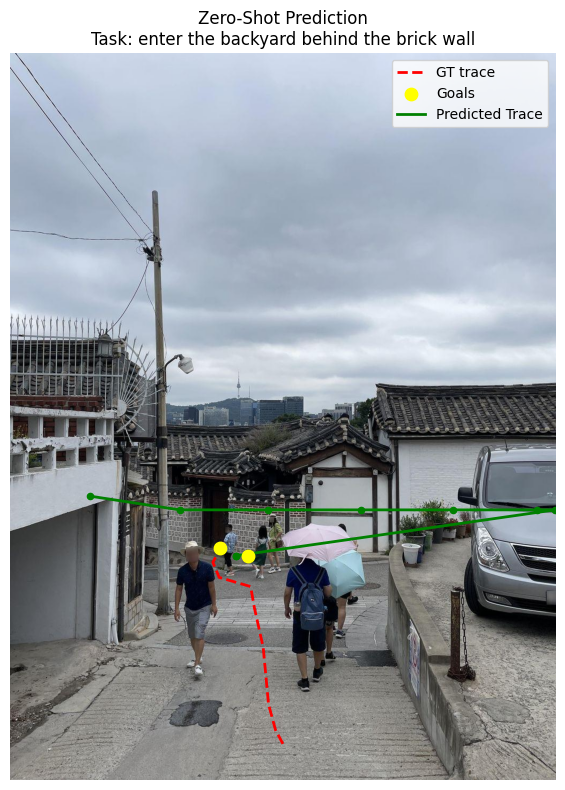

In [235]:
# testing the zero-shot prompt on a few test samples before training any model
sample = val_samples[0]
print(f"\nTask: {sample['task']}")

zs_result = zero_shot_prompt(sample, CFG["trace_points"])
print(f"Zero-shot result: {zs_result}")
visualize_trace_with_ground_truth(sample, zs_result, title="Zero-Shot Prediction")
    

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Task: enter the backyard behind the brick wall
CoT result: {'goal': [0.48, 0.669], 'trace': [[155.735, 783.51], [391.88, 753.48], [641.675, 753.48], [821.855, 753.48], [1023.0, 753.48], [484.69999999999993, 913.1850000000001]]}


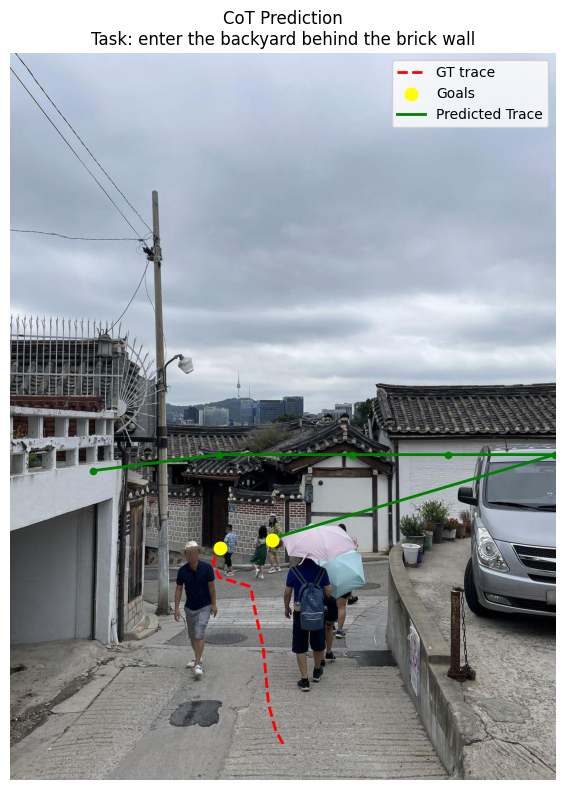

In [208]:
# CoT prompting test
sample = val_samples[0]
print(f"\nTask: {sample['task']}")

cot_result = cot_prompt(sample, CFG["trace_points"])
print(f"CoT result: {cot_result}")
visualize_trace_with_ground_truth(sample, cot_result, title="CoT Prediction")


# Save JSON file

### Saving Zero-shot to json

In [ ]:
for sample in val_samples[:5]:
    zs_result = zero_shot_prompt(sample, CFG["trace_points"])

    if zs_result is not None:
        sample_id = sample.get("sample_id", sample.get("id", "unknown"))

        output = {
            "sample_id": sample_id,
            "task": sample["task"],
            "goal": zs_result["goal"],
            "trace": zs_result["trace"],
        }

        with open(os.path.join(CFG["output_root"], f"{sample_id}_zs_output.json"), "w") as f:
            json.dump(output, f, indent=2)

            # print(f"Saved zero-shot output for sample {sample_id}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved zero-shot output for sample 7cd1e880-81e4-4407-a8df-0ebe2f16e958


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved zero-shot output for sample 7feff4cb-45f4-47cb-8781-413bbe90e2bc


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved zero-shot output for sample 996adb54-09e5-4f74-abe2-2a821be73ad4


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved zero-shot output for sample 37d45e1d-5ee6-4c94-96d4-12faf1dccd80
Saved zero-shot output for sample 00c50fd8-99c3-41b9-bead-1c69a5949099


### Saving CoT to JSON

In [198]:
for sample in val_samples[:5]:

    cot_result = cot_prompt(sample, CFG["trace_points"])

    if cot_result is not None:
        sample_id = sample.get("sample_id", sample.get("id", "unknown"))

        output = {
            "sample_id": sample_id,
            "task": sample["task"],
            "goal": cot_result["goal"],
            "trace": cot_result["trace"],
        }

        with open(os.path.join(CFG["output_root"], f"{sample_id}_cot_output.json"), "w") as f:
            json.dump(output, f, indent=2)

            print(f"Saved chain-of-thought output for sample {sample_id}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved chain-of-thought output for sample 7cd1e880-81e4-4407-a8df-0ebe2f16e958


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved chain-of-thought output for sample 7feff4cb-45f4-47cb-8781-413bbe90e2bc


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved chain-of-thought output for sample 996adb54-09e5-4f74-abe2-2a821be73ad4


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saved chain-of-thought output for sample 37d45e1d-5ee6-4c94-96d4-12faf1dccd80
Saved chain-of-thought output for sample 00c50fd8-99c3-41b9-bead-1c69a5949099


## Save to .tsv using Testset

### Zero-shot .tsv

In [256]:
results = []
for sample in test_samples:
    zs_result = zero_shot_prompt(sample, CFG["trace_points"])

    img            = sample["image"]
    orig_w, orig_h = img.size
    pred_px        = pred_padded_to_pixel(zs_result["trace"], orig_w, orig_h)
    results.append({
        "sample_id":  sample["sample_id"],
        "embodiment": CFG["embodiment"],
        "category":  sample["category"],
        "prediction": pred_px,
    })

pd.DataFrame(results).to_csv("./zero_shot_predictions.tsv", sep="\t", index=False) 

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Was not able to process prediction: [[0.0, 0.0, 0.248, 0.988], [0.248, 0.0, 0.492, 0.988], [0.492, 0.0, 0.734, 0.988], [0.734, 0.0, 0.998, 0.988], [0.408, 0.691, 0.734, 0.988], [0.734, 0.691, 0.998, 0.988], [0.408, 0.691, 0.734, 0.988], [0.734, 0.691, 0.998, 0.988], [0.408, 0.691]]


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

### CoT Prompting .tsv save

In [262]:
results = []
for sample in test_samples:
    cot_result = cot_prompt(sample, CFG["trace_points"])
    # print(colt_result)

    img            = sample["image"]
    orig_w, orig_h = img.size
    pred_px        = pred_padded_to_pixel(cot_result["trace"], orig_w, orig_h)
    results.append({
        "sample_id":  sample["sample_id"],
        "embodiment": CFG["embodiment"],
        "category":  sample["category"],
        "prediction": pred_px,
    })

pd.DataFrame(results).to_csv("./cot_predictions.tsv", sep="\t", index=False) 

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


### Evaluation Helpers

In [209]:
@functools.lru_cache(maxsize=4)
def penalty_lookup(embodiment):
    df  = pd.read_csv(CFG["penalty_tsv"], sep="\t")
    with open(CFG["m2f_config"]) as f:
        m2f = json.load(f)
    id2label = {int(k): v for k, v in m2f["id2label"].items()}
    lkp = {}
    for lid, name in id2label.items():
        row = df[df["category"] == name]
        lkp[lid] = float(row.iloc[0][embodiment]) * 0.8 if len(row) else 0.0
    return lkp

def rasterize(trace, H, W):
    pts, pixels = np.array(trace), []
    if len(pts) > 1:
        for i in range(len(pts)-1):
            r0,c0=int(round(pts[i][1])),int(round(pts[i][0]))
            r1,c1=int(round(pts[i+1][1])),int(round(pts[i+1][0]))
            rr,cc,_=line_aa(r0,c0,r1,c1)
            v=(rr>=0)&(rr<H)&(cc>=0)&(cc<W)
            pixels.extend(zip(rr[v],cc[v]))
    elif len(pts)==1:
        r,c=int(round(pts[0][1])),int(round(pts[0][0]))
        if 0<=r<H and 0<=c<W: pixels.append((r,c))
    return np.array(pixels)

def penalty_mask(seg, gt_px, emb, dthr=35):
    H,W=seg.shape; mask=np.zeros((H,W),dtype=float)
    lkp=penalty_lookup(emb); gtp=rasterize(gt_px,H,W)
    if len(gtp)==0: return mask
    tree=KDTree(gtp); ids=seg.ravel()
    und=np.where(np.isin(ids,list(lkp.keys())))[0]
    if und.size==0: return mask
    rows,cols=np.unravel_index(und,(H,W))
    coords=np.vstack((rows,cols)).T
    dist,_=tree.query(coords); pen_idx=coords[dist>dthr]
    if pen_idx.size>0:
        rp,cp=pen_idx[:,0],pen_idx[:,1]
        mask[rp,cp]=np.vectorize(lkp.get)(seg[rp,cp],0)
    return mask

def sem_penalty(pred_px, pmask):
    H,W=pmask.shape; vals=[]
    for i in range(len(pred_px)-1):
        x1,y1=int(round(pred_px[i][0])),int(round(pred_px[i][1]))
        x2,y2=int(round(pred_px[i+1][0])),int(round(pred_px[i+1][1]))
        rr,cc=sk_line(y1,x1,y2,x2)
        v=(rr>=0)&(rr<H)&(cc>=0)&(cc<W)
        vals.extend(pmask[rr[v],cc[v]].tolist())
    return float(np.mean(vals)) if vals else 0.0

def calc_fde(p,g):
    return float(np.linalg.norm(np.array(p[-1])-np.array(g[-1])))

def calc_dtw(p,g):
    p=np.array(p,dtype=float); g=np.array(g,dtype=float)
    if len(p)!=len(g):
        longer,shorter=(p,g) if len(p)>=len(g) else (g,p)
        d=np.cumsum([0]+[np.linalg.norm(shorter[i]-shorter[i-1])
                         for i in range(1,len(shorter))])
        tot=d[-1]
        if tot>0: d=d/tot
        t=np.linspace(0,1,len(longer))
        shorter=np.column_stack([np.interp(t,d,shorter[:,0]),
                                  np.interp(t,d,shorter[:,1])])
        p,g=(longer,shorter) if len(p)>=len(g) else (shorter,longer)
    n,m=len(p),len(g); D=np.full((n+1,m+1),np.inf); D[0,0]=0
    for i in range(1,n+1):
        for j in range(1,m+1):
            D[i,j]=np.linalg.norm(p[i-1]-g[j-1])+min(D[i-1,j],D[i,j-1],D[i-1,j-1])
    return float(D[n,m])

def norm_score(raw):
    return (CFG["bad_score_threshold"]-raw)/CFG["bad_score_threshold"]*100

In [222]:
def evaluate_prompting_method(prompt_fn, samples, method_name):
    trace_px, nt_scores, dtw_scores, fde_scores, pen_scores = [], [], [], [], []
    invalid_json = 0
    raw_generations = []

    for sample in tqdm(samples, desc=f"Evaluating {method_name}"):
        result = prompt_fn(sample, CFG["trace_points"])

        raw_generations.append({
            "sample_id": sample.get("sample_id", "unknown"),
            "result": result,
        })

        if result is None:
            invalid_json += 1
            trace_px = [[sample["image"].width / 2, sample["image"].height / 2]] * CFG["trace_points"]
        else:
            trace_px = result["trace"]

        trace_px = [[float(pt[0]), float(pt[1])] for pt in trace_px if len(pt) >= 2]

        if len(trace_px) == 0:
            invalid_json += 1
            trace_px = [[org_w/2, org_h/2]] * CFG["trace_points"]

        img = sample["image"].convert("RGB")
        orig_w, orig_h = img.size
        seg = np.array(sample["segmentation_mask"])

        gt_trace = sample["ground_truth"].get(CFG["embodiment"], [])
        best_raw = best_d = best_f = best_p = float('inf')

        for gt in gt_trace:
            gt_px = [[float(pt[0]), float(pt[1])] for pt in gt if len(pt) >= 2]

            pmask = penalty_mask(seg, gt, CFG["embodiment"], CFG["penalty_dist_thr"])
            p_val = sem_penalty(trace_px, pmask)
            f_val = calc_fde(trace_px, gt)
            d_val = calc_dtw(trace_px, gt)
            raw = d_val + f_val + p_val
            if raw < best_raw:
                best_raw, best_d, best_f, best_p = raw, d_val, f_val, p_val

        nt_scores.append(norm_score(best_raw))
        dtw_scores.append(best_d)
        fde_scores.append(best_f)
        pen_scores.append(best_p)

    metrics = {
        "method": method_name,
        "prediction_points": trace_px,
        "trace_score_mean": np.mean(nt_scores),
        "trace_score_std": np.std(nt_scores),
        "dtw_mean": np.mean(dtw_scores),
        "fde_mean": np.mean(fde_scores),
        "penalty_mean": np.mean(pen_scores),
        "invalid_json": invalid_json,
        "num_scored": len(nt_scores),
    }

    print(f"\n{method_name} Evaluation Metrics:")
    print(f"Trace Score (normalized): {metrics['trace_score_mean']:.2f} ± {metrics['trace_score_std']:.2f}")
    print(f"DTW Distance Mean: {metrics['dtw_mean']:.2f}")
    print(f"FDE Mean: {metrics['fde_mean']:.2f}")
    print(f"Penalty Mean: {metrics['penalty_mean']:.2f}")
    print(f"Invalid JSON Outputs: {metrics['invalid_json']} / {metrics['num_scored']}")

    return metrics, pd.DataFrame(raw_generations)

### Validation Evaluation

In [ ]:

zs_metrics, zs_raw = evaluate_prompting_method(zero_shot_prompt, val_samples, "Zero-Shot")
cot_metrics, cot_raw = evaluate_prompting_method(cot_prompt, val_samples, "Chain-of-Thought")

results_df = pd.DataFrame([zs_metrics, cot_metrics])
results_df = results_df.sort_values("trace_score_mean", ascending=False)
print("\n", results_df[["method", "trace_score_mean", "dtw_mean", "fde_mean", "penalty_mean", "invalid_json"]])

Evaluating Zero-Shot:   0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o


Zero-Shot Evaluation Metrics:
Trace Score (normalized): -121.87 ± 79.66
DTW Distance Mean: 6093.28
FDE Mean: 640.03
Penalty Mean: 443.53
Invalid JSON Outputs: 0 / 100


Evaluating Chain-of-Thought:   0%|          | 0/100 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


...

Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Error decoding JSON from model output!


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



Chain-of-Thought Evaluation Metrics:
Trace Score (normalized): -104.88 ± 71.73
DTW Distance Mean: 5608.87
FDE Mean: 579.79
Penalty Mean: 438.61
Invalid JSON Outputs: 9 / 100

              method  trace_score_mean     dtw_mean    fde_mean  penalty_mean  \
1  Chain-of-Thought       -104.877350  5608.870998  579.793901    438.605165   
0         Zero-Shot       -121.866997  6093.281565  640.034588    443.526521   

   invalid_json  
1             9  
0             0  
